Импортируем необходимые библиотеки

In [1]:
# Базовые математические функции
import math
# Основная библиотека PyTorch для тензорных вычислений и глубокого обучения
import torch         
# Подмодуль PyTorch для создания нейронных сетей (слоёв, модулей)
import torch.nn as nn 
# Подмодуль PyTorch для алгоритмов оптимизации (SGD, Adam и т.д.)
import torch.optim as optim 
# Подмодуль PyTorch для работы с датасетами и DataLoader'ами
import torch.utils.data as data 
# Библиотека PyTorch для задач компьютерного зрения, содержит популярные датасеты и трансформации
import torchvision  
# Трансформации для предобработки изображений (ToTensor, Normalize и др.)
import torchvision.transforms as transforms 
# Библиотека для работы с массивами
import numpy as np        
# Библиотека для визуализации (графиков, изображений)
import matplotlib.pyplot as plt 
# Библиотека для взаимодействия с операционной системой (работа с путями, файлами)
import os  
# Для сериализации данных (архитектуры модели) в формат JSON
import json    
# Для записи результатов экспериментов в формат CSV (таблица)   
import csv                     

Устанавливаем воспроизводимость результатов

In [2]:
SEED = 42  # Фиксированное значение для генераторов случайных чисел
torch.manual_seed(SEED)
# Проверяем доступность GPU (CUDA). Если есть — фиксируем seed и для него.
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Определяем устройство

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Выводим текущее устройство для отладки и контроля
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


Загружаем датасет

In [4]:
DATASET_NAME = "EMNIST"
print(f"Загружаем датасет B: {DATASET_NAME} (split='balanced')")

Загружаем датасет B: EMNIST (split='balanced')


Определяем `transform`

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Загружаем полную обучающую  и тестовую часть датасета

In [ ]:
# Загружаем полную обучающую часть
train_full_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='balanced',
    train=True,
    download=True,
    transform=transform
)
# Загружаем тестовую часть
test_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='balanced',
    train=False,
    download=True,
    transform=transform
)

 67%|██████▋   | 375M/562M [00:30<00:14, 13.3MB/s] 

Получаем информацию о структуре данных

In [ ]:
img_shape = train_full_dataset[0][0].shape[1:]  
input_size = img_shape[0] * img_shape[1]        
num_classes = len(train_full_dataset.classes)   
print(f"Форма изображения (H, W): {img_shape}")
print(f"Размер входа (flatten): {input_size}")
print(f"Количество классов: {num_classes}")

Форма изображения (H, W): torch.Size([28, 28])
Размер входа (flatten): 784
Количество классов: 47


Делаем разбиение `train/val` из train-части с фиксированным seed

In [ ]:
# Вычисляем размеры: 80% — train, 20% — val
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size
# Разбиваем датасет с фиксированным генератором (воспроизводимость!)
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = data.random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=generator
)
# Выводим размеры для контроля
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 90240
Val size: 22560
Test size: 18800


Создаем `DataLoader` для train/val/test

In [ ]:
BATCH_SIZE = 64  # Размер батча (стандартный для MLP)
# DataLoader для обучающей выборки: shuffle=True — перемешивание важна для обучения
train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,        
    pin_memory=False      
)
# DataLoader для валидационной выборки: shuffle=False — порядок не важен
val_loader = data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
# DataLoader для тестовой выборки: shuffle=False — только для оценки в конце
test_loader = data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
# Выводим количество батчей для контроля
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 1410 | Val batches: 353 | Test batches: 294


Показываем `sanity-check`

In [ ]:
# Получаем первый батч из train_loader
x_batch, y_batch = next(iter(train_loader))
# Проверяем формы:
print(f"x_batch.shape: {x_batch.shape}")      
print(f"y_batch.shape: {y_batch.shape}")      
# Проверяем типы данных:
print(f"x_batch.dtype: {x_batch.dtype}")      
print(f"y_batch.dtype: {y_batch.dtype}")      
# Проверяем диапазон значений (после Normalize(0.5, 0.5) → [-1, 1]):
print(f"x_batch.min(): {x_batch.min():.4f}, x_batch.max(): {x_batch.max():.4f}")
# Пример меток (первые 10):
print(f"Пример меток (первые 10): {y_batch[:10]}")
# Проверка перемещения на device (важно для GPU-обучения)
x_on_dev = x_batch.to(device, non_blocking=True)  
y_on_dev = y_batch.to(device, non_blocking=True)
print(f"x_on_device.device: {x_on_dev.device}")  
print(f"y_on_device.device: {y_on_dev.device}")

x_batch.shape: torch.Size([64, 1, 28, 28])
y_batch.shape: torch.Size([64])
x_batch.dtype: torch.float32
y_batch.dtype: torch.int64
x_batch.min(): -1.0000, x_batch.max(): 1.0000
Пример меток (первые 10): tensor([32,  3, 36, 29, 28, 23, 39,  2,  9, 10])
x_on_device.device: cpu
y_on_device.device: cpu


Определяем архитектуру нейронной сети (MLP) как класс, наследующийся от nn.Module

In [ ]:
class MLP(nn.Module):
    """
    Простой многослойный перцептрон (MLP) с возможностью добавления Dropout и BatchNorm.
    """
    def __init__(self, input_dim, hidden_dims, num_classes, activation='relu', use_batchnorm=False, dropout_p=0.0):
        """
        Конструктор модели.
        :param input_dim: Размерность входного вектора (например, 784 для 28x28 изображений).
                           Взято из результатов 2.3.2 как input_size.
        :param hidden_dims: Кортеж или список размеров скрытых слоёв (например, [256, 128]).
        :param num_classes: Количество выходных классов (например, 47 для EMNIST balanced).
                            Взято из результатов 2.3.2 как num_classes.
        :param activation: Функция активации ('relu', 'tanh', 'gelu').
        :param use_batchnorm: Использовать ли BatchNorm1d между Linear и активацией.
        :param dropout_p: Вероятность отключения нейрона в Dropout (0.0 = нет dropout).
        """
        # Вызываем конструктор родительского класса nn.Module
        super(MLP, self).__init__()
        # Выбираем функцию активации из словаря
        # Если активация не найдена, по умолчанию используется ReLU
        act_layer = {
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'gelu': nn.GELU,
        }.get(activation.lower(), nn.ReLU)
        # Инициализируем список слоёв
        layers = [nn.Flatten()]
        # Настраиваем размерность для первого слоя
        prev_dim = input_dim
        # Проходим по размерам скрытых слоёв и добавляем их в список layers
        for hidden_dim in hidden_dims:
            # Добавляем линейный слой: предыдущий размер -> текущий размер
            layers.append(nn.Linear(prev_dim, hidden_dim))
            # Добавляем BatchNorm1d, если указано
            # BatchNorm помогает стабилизировать обучение
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            # Добавляем функцию активации
            layers.append(act_layer())
            # Добавляем Dropout, если вероятность > 0
            # Dropout помогает бороться с переобучением
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            # Обновляем предыдущую размерность для следующего слоя
            prev_dim = hidden_dim
        # Добавляем финальный линейный слой: последний скрытый слой -> количество классов
        # Этот слой выдает "логиты" - сырые оценки для каждого класса.
        layers.append(nn.Linear(prev_dim, num_classes))
        # Объединяем все слои в последовательный модуль (Sequential)
        # Это и будет наша нейронная сеть
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        """
        Метод, определяющий прямой проход (forward pass) через сеть.
        :param x: Входной тензор (батч изображений).
        :return: Логиты (оценки) для каждого класса.
        """
        # Пропускаем входной тензор через последовательность слоёв
        return self.net(x)

Проверяем архитектуру модели

In [ ]:
# Создаём экземпляр модели с заданными параметрами

model_input_dim = input_size  
model_hidden_dims = (256, 128) 
model_num_classes = num_classes 
model_activation = 'relu'       # Выбранная функция активации
model_use_batchnorm = True      # Включаем BatchNorm (для E3)
model_dropout_p = 0.3           # Вероятность Dropout (для E2/E4)
# Создаём модель с включёнными BatchNorm и Dropout
model = MLP(
    input_dim=model_input_dim,
    hidden_dims=model_hidden_dims,
    num_classes=model_num_classes,
    activation=model_activation,
    use_batchnorm=model_use_batchnorm,
    dropout_p=model_dropout_p
).to(device) # Перемещаем модель на выбранное устройство (CPU или GPU)
# Выводим архитектуру модели и количество обучаемых параметров
print("Архитектура модели")
print(model)
# Подсчитываем количество обучаемых параметров (веса и смещения)
# p.numel() возвращает количество элементов в тензоре параметра
# p.requires_grad проверяет, обучается ли этот параметр
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Общее количество обучаемых параметров: {n_params}")

Архитектура модели
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=47, bias=True)
  )
)
Общее количество обучаемых параметров: 240687


Определяем функцию потерь и оптимизатор

In [ ]:
# Определяем функцию потерь (loss function)
criterion = nn.CrossEntropyLoss()
# Определяем оптимизатор
LEARNING_RATE = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Выводим информацию об оптимизаторе (для отладки и контроля)
print(f"Оптимизатор: {type(optimizer).__name__}")
print(f"Learning Rate: {optimizer.param_groups[0]['lr']}")

Оптимизатор: Adam
Learning Rate: 0.001


`Sanity-check`

In [ ]:
# Проверяем, что модель, loss и optimizer могут работать вместе
# Берём один батч из train_loader
print("Sanity-check: прогон одного батча")
# Устанавливаем модель в режим оценки (важно для Dropout и BatchNorm)
# В этом режиме Dropout не выключает нейроны, а BatchNorm использует накопленные статистики.
model.eval()
# Отключаем вычисление градиентов для этой проверки (экономия памяти и времени)
with torch.no_grad():
    # Получаем первый батч из train_loader
    x_batch_sample, y_batch_sample = next(iter(train_loader))
    # Перемещаем батч на устройство модели (CPU или GPU)
    x_batch_sample = x_batch_sample.to(device, non_blocking=True)
    y_batch_sample = y_batch_sample.to(device, non_blocking=True)
    # Пропускаем батч через модель
    logits_sample = model(x_batch_sample)
    # Вычисляем loss
    loss_sample = criterion(logits_sample, y_batch_sample)
    # Проверяем форму выхода: [batch_size, num_classes]
    print(f"Форма входа (x_batch): {x_batch_sample.shape}")
    print(f"Форма выхода модели (logits): {logits_sample.shape}")
    print(f"Форма меток (y_batch): {y_batch_sample.shape}")
    print(f"Значение loss: {loss_sample.item():.4f}")
    # Проверяем, что форма соответствует ожидаемой
    expected_shape = (x_batch_sample.shape[0], model_num_classes)
    assert logits_sample.shape == expected_shape, f"Форма выхода {logits_sample.shape} != {expected_shape}"
    print("Sanity-check пройден: модель, loss и optimizer успешно работают вместе.")
# Возвращаем модель в режим обучения (для начала тренировки)
# В этом режиме Dropout активен, и BatchNorm обновляет свои статистики.
model.train()
print("Модель переведена в режим обучения (model.train()).")

Sanity-check: прогон одного батча
Форма входа (x_batch): torch.Size([64, 1, 28, 28])
Форма выхода модели (logits): torch.Size([64, 47])
Форма меток (y_batch): torch.Size([64])
Значение loss: 3.8679
Sanity-check пройден: модель, loss и optimizer успешно работают вместе.
Модель переведена в режим обучения (model.train()).


Создаем функцию одной эпохи обучения

In [ ]:
# Определяем функцию для выполнения одного прохода по обучающей выборке
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """
    Обучает модель на одном эпохе данных из train_loader.
    Возвращает средние loss и accuracy по батчам эпохи.
    """
    # Переводим модель в режим обучения (включает Dropout, BatchNorm в обучаемом режиме)
    model.train()
    # Инициализируем суммарный loss и количество корректных предсказаний
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    # Итерируемся по батчам из train_loader
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Перемещаем данные (изображения и метки) на целевое устройство (CPU или GPU)
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        # Обнуляем градиенты предыдущего шага
        # Это критически важно, так как PyTorch накапливает градиенты.
        optimizer.zero_grad(set_to_none=True) # set_to_none быстрее, чем .zero_()
        # Выполняем прямой проход (forward pass) через модель
        outputs = model(x_batch)
        # Вычисляем loss между предсказаниями и истинными метками
        loss = criterion(outputs, y_batch)
        # Выполняем обратный проход (backward pass) для вычисления градиентов
        loss.backward()
        # Обновляем параметры модели с помощью оптимизатора
        optimizer.step()
        # Суммируем loss для всей эпохи
        running_loss += loss.item() # .item() извлекает скалярное значение из тензора
        # Вычисляем количество правильных предсказаний для accuracy
        _, predicted = torch.max(outputs.data, 1)
        # Сравниваем прогнозы с истинными метками и суммируем совпадения
        correct_predictions += (predicted == y_batch).sum().item()
        # Суммируем общее количество образцов в батче
        total_samples += y_batch.size(0)
    # Вычисляем средний loss и accuracy для всей эпохи
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct_predictions / total_samples
    # Возвращаем вычисленные значения
    return epoch_loss, epoch_acc

Создаем функцию оценки (валидации/тестирования)

In [ ]:
# Определяем функцию для оценки модели на валидационной или тестовой выборке
def evaluate(model, data_loader, criterion, device):
    """
    Оценивает модель на данных из data_loader (val или test).
    Возвращает средние loss и accuracy.
    """
    # Переводим модель в режим оценки (отключает Dropout, BatchNorm использует обученные статистики)
    model.eval()
    # Инициализируем суммарный loss и количество корректных предсказаний
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    # Блок torch.no_grad() отключает вычисление градиентов
    with torch.no_grad():
        # Итерируемся по батчам из data_loader (val_loader или test_loader)
        for x_batch, y_batch in data_loader:
            # Перемещаем данные на целевое устройство
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            # Выполняем прямой проход через модель
            outputs = model(x_batch)
            # Вычисляем loss
            loss = criterion(outputs, y_batch)
            # Суммируем loss
            running_loss += loss.item()
            # Вычисляем количество правильных предсказаний
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == y_batch).sum().item()
            total_samples += y_batch.size(0)
    # Вычисляем средний loss и accuracy для всей выборки
    avg_loss = running_loss / len(data_loader)
    avg_acc = correct_predictions / total_samples
    # Возвращаем вычисленные значения
    return avg_loss, avg_acc

Проверяем работу функций на одном батче

In [ ]:
# Создаем подмножество данных для быстрой проверки (например, 1 батч)
# Это не полноценная эпоха, но проверяет, что код выполняется без ошибок.
sample_loader = torch.utils.data.DataLoader(
    torch.utils.data.Subset(train_dataset, range(BATCH_SIZE)), # Первые BATCH_SIZE элементов
    batch_size=BATCH_SIZE,
    shuffle=False
)
# Вызываем функцию обучения на одном батче
loss, acc = train_one_epoch(model, sample_loader, optimizer, criterion, device)
print(f"Loss на одном батче (train): {loss:.4f}, Acc: {acc:.4f}")
# Вызываем функцию оценки на одном батче
val_loss, val_acc = evaluate(model, sample_loader, criterion, device)
print(f"Loss на одном батче (eval): {val_loss:.4f}, Acc: {val_acc:.4f}")
# Проверка, что функции возвращают числа
assert isinstance(loss, float), f"train_one_epoch должна возвращать float для loss, получено {type(loss)}"
assert isinstance(acc, float), f"train_one_epoch должна возвращать float для acc, получено {type(acc)}"
assert isinstance(val_loss, float), f"evaluate должна возвращать float для loss, получено {type(val_loss)}"
assert isinstance(val_acc, float), f"evaluate должна возвращать float для acc, получено {type(val_acc)}"
print("Sanity-check прой train_one_epoch и evaluate работают корректно.")

Loss на одном батче (train): 4.0842, Acc: 0.0000
Loss на одном батче (eval): 3.8209, Acc: 0.0156
Sanity-check прой train_one_epoch и evaluate работают корректно.


Определяем класс EarlyStopping

In [ ]:
class EarlyStopping:
    """
    Помогает избежать переобучения, останавливая обучение, если метрика (например, val_loss) не улучшается.
    Сохраняет состояние лучшей модели на момент остановки.
    """
    def __init__(self, patience: int = 5, min_delta: float = 0.0, metric_for_best: str = 'loss', mode: str = 'min'):
        """
        Инициализация EarlyStopping.
        :param patience: Количество эпох, в течение которых метрика может не улучшаться, прежде чем обучение будет остановлено.
        :param min_delta: Минимальное изменение метрики, которое считается улучшением.
        :param metric_for_best: 'loss' или 'accuracy'. Определяет, какая метрика используется для определения "лучшей" модели.
        :param mode: 'min' (меньше - лучше, напр. loss) или 'max' (больше - лучше, напр. accuracy).
        """
        # Сохраняем параметры остановки
        self.patience = patience # Количество эпох без улучшения
        self.min_delta = min_delta # Минимальное улучшение
        self.metric_for_best = metric_for_best # Какая метрика используется для отбора лучшей модели
        # Определяем функцию сравнения в зависимости от mode
        self._is_better = (lambda curr, best: curr > best + self.min_delta) if mode == 'max' else (lambda curr, best: curr < best - self.min_delta)
        # Инициализируем внутренние переменные состояния
        self.best_score = None # Хранит лучшее значение метрики
        self.best_state = None # Хранит state_dict лучшей модели
        self.counter = 0 # Счетчик эпох без улучшения
    def step(self, score: float, model: nn.Module) -> bool:
        """
        Вызывается в конце эпохи.
        :param score: Текущее значение метрики (например, val_acc или val_loss).
        :param model: Объект модели PyTorch.
        :return: True, если нужно остановить обучение, иначе False.
        """
        # Если это первая эпоха, сохраняем текущий результат как лучший
        if self.best_score is None:
            self.best_score = score
            # Сохраняем состояние модели (веса) как "лучшее" состояние
            # detach().clone() гарантирует, что сохраненная версия не изменится
            # .cpu() перемещает веса на CPU для сохранения
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False # Не останавливаем
        # Проверяем, улучшилась ли метрика по сравнению с лучшим результатом
        if self._is_better(score, self.best_score):
            # Если улучшилась, обновляем лучший результат и сбрасываем счетчик
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            # Если не улучшилась, увеличиваем счетчик
            self.counter += 1
        # Возвращаем True, если счетчик достиг порога (patience), иначе False
        return self.counter >= self.patience
    def load_best_weights(self, model: nn.Module):
        """
        Загружает состояние лучшей модели, сохраненной в best_state.
        :param model: Объект модели PyTorch, в которую нужно загрузить веса.
        """
        # Проверяем, что лучшее состояние было сохранено
        if self.best_state is not None:
            # Загружаем сохраненные веса в модель
            model.load_state_dict(self.best_state)
        else:
            print("Предупреждение: best_state не найдено. Невозможно загрузить веса.")

Функция для построения графиков

In [ ]:
def plot_history(history, title="Training History", save_path=None):
    """
    Строит графики loss и accuracy для обучающей и валидационной выборок.
    :param history: Словарь с ключами ['train_loss', 'val_loss', 'train_acc', 'val_acc'].
                    Каждый ключ содержит список значений по эпохам.
    :param title: Заголовок графика.
    :param save_path: Путь для сохранения графика (если указан).
    """
    # Получаем количество эпох из истории
    epochs = range(1, len(history['train_loss']) + 1)
    # Создаем фигуру с двумя подграфиками (subplots)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    # Левый график: Loss
    # Рисуем кривые loss для train и val
    ax[0].plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    ax[0].plot(epochs, history['val_loss'], label='Validation Loss', marker='s')
    # Настраиваем ось X и Y
    ax[0].set_title(f'{title} - Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Loss')
    # Добавляем легенду
    ax[0].legend()
    # Добавляем сетку для лучшей читаемости
    ax[0].grid(True)
    # Правый график: Accuracy
    # Рисуем кривые accuracy для train и val
    ax[1].plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    ax[1].plot(epochs, history['val_acc'], label='Validation Accuracy', marker='s')
    # Настраиваем ось X и Y
    ax[1].set_title(f'{title} - Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Accuracy')
    # Добавляем легенду
    ax[1].legend()
    # Добавляем сетку
    ax[1].grid(True)
    # Улучшаем расположение подграфиков
    plt.tight_layout()
    # Сохраняем график, если указан путь
    if save_path:
        # Создаем директорию, если она не существует
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранен: {save_path}")
    # Отображаем график
    plt.show()

Задаем общие параметры для экспериментов E1-E4

In [ ]:
EPOCHS_E1_E2_E3 = 20  # Количество эпох для E1, E2, E3
BASE_HIDDEN_SIZES = (256, 128)  # Архитектура скрытых слоёв (одинаковая для E1-E3)
BASE_ACTIVATION = 'relu'        # Функция активации (одинаковая для E1-E3)
BASE_LR = 1e-3                  # Learning rate для Adam (одинаковый для E1-E3)
# Параметры для EarlyStopping в E4
ES_PATIENCE = 4                 # Количество эпох без улучшения val_acc, после которых останавливаемся
ES_MIN_DELTA = 0.0005           # Минимальное улучшение val_acc, чтобы считалось за прогресс
ES_EPOCHS_MAX = 50              # Максимальное количество эпох для E4 (на случай, если EarlyStopping не сработает)

Реализуем эксперимент E1 (base)

Начало эксперимента E1 (Base)
E1 Epoch 01/20| Train Loss: 1.1658, Acc: 0.6569| Val Loss: 0.7816, Acc: 0.7607
E1 Epoch 02/20| Train Loss: 0.6732, Acc: 0.7850| Val Loss: 0.6301, Acc: 0.7984
E1 Epoch 03/20| Train Loss: 0.5715, Acc: 0.8105| Val Loss: 0.5860, Acc: 0.8100
E1 Epoch 04/20| Train Loss: 0.5160, Acc: 0.8260| Val Loss: 0.5417, Acc: 0.8208
E1 Epoch 05/20| Train Loss: 0.4795, Acc: 0.8350| Val Loss: 0.5456, Acc: 0.8195
E1 Epoch 06/20| Train Loss: 0.4500, Acc: 0.8423| Val Loss: 0.5591, Acc: 0.8160
E1 Epoch 07/20| Train Loss: 0.4268, Acc: 0.8481| Val Loss: 0.5268, Acc: 0.8291
E1 Epoch 08/20| Train Loss: 0.4069, Acc: 0.8543| Val Loss: 0.5401, Acc: 0.8286
E1 Epoch 09/20| Train Loss: 0.3910, Acc: 0.8571| Val Loss: 0.5296, Acc: 0.8344
E1 Epoch 10/20| Train Loss: 0.3769, Acc: 0.8629| Val Loss: 0.5287, Acc: 0.8293
E1 Epoch 11/20| Train Loss: 0.3617, Acc: 0.8666| Val Loss: 0.5400, Acc: 0.8272
E1 Epoch 12/20| Train Loss: 0.3526, Acc: 0.8680| Val Loss: 0.5598, Acc: 0.8258
E1 Epoch 13/20| Train 

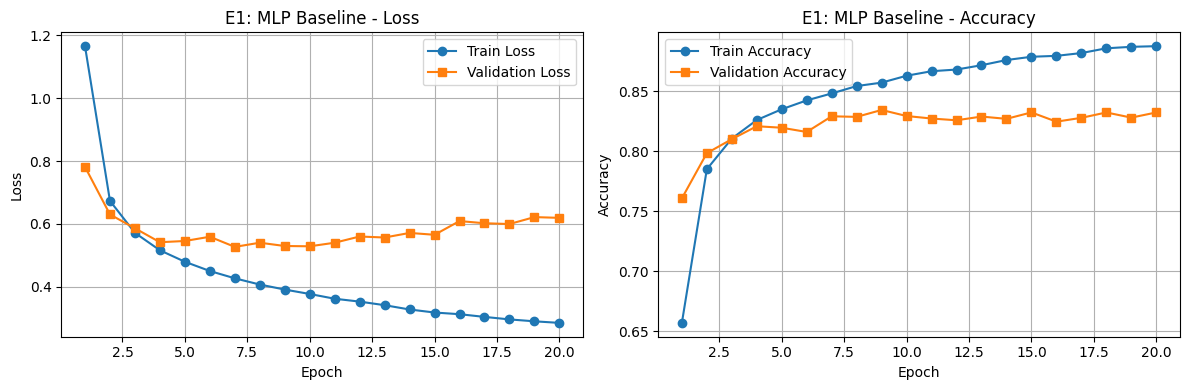

In [ ]:
print("Начало эксперимента E1 (Base)")
# Создаём модель для E1: MLP без Dropout и BatchNorm
model_e1 = MLP(
    input_dim=input_size,       
    hidden_dims=BASE_HIDDEN_SIZES,
    num_classes=num_classes,    
    activation=BASE_ACTIVATION,
    use_batchnorm=False,        
    dropout_p=0.0               
).to(device) # Перемещаем модель на устройство (CPU или GPU)
# Определяем loss и optimizer для E1
criterion_e1 = nn.CrossEntropyLoss()
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=BASE_LR)
# Обучаем модель E1
history_e1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(EPOCHS_E1_E2_E3):
    tr_loss, tr_acc = train_one_epoch(model_e1, train_loader, optimizer_e1, criterion_e1, device)
    val_loss, val_acc = evaluate(model_e1, val_loader, criterion_e1, device)
    history_e1['train_loss'].append(tr_loss)
    history_e1['train_acc'].append(tr_acc)
    history_e1['val_loss'].append(val_loss)
    history_e1['val_acc'].append(val_acc)
    print(f"E1 Epoch {epoch+1:02d}/{EPOCHS_E1_E2_E3}| Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f}| Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
# Оцениваем модель E1 на тесте
test_loss_e1, test_acc_e1 = evaluate(model_e1, test_loader, criterion_e1, device)
print(f"E1 Final Test Loss: {test_loss_e1:.4f}, Test Acc: {test_acc_e1:.4f}")
# Построим график для E1 (опционально, если функция plot_history определена)
plot_history(history_e1, title="E1: MLP Baseline")
# Сохраняем модель под именем model_E1
model_E1 = model_e1  # Копируем объект модели
# Сохраняем историю под именем history_E1
history_E1 = history_e1  # Копируем словарь истории
# Сохраняем результаты в словарь results_E1 для runs.csv
results_E1 = {
    'experiment_id': 'E1',
    'dataset': DATASET_NAME,  
    'seed': SEED,             
    'model_summary': f"hidden={BASE_HIDDEN_SIZES}, act={BASE_ACTIVATION}, bn=False, dp=0.0",
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0.0,         # Adam не использует momentum напрямую
    'weight_decay': 0.0,     # Какой был weight_decay (в данном случае 0)
    'epochs_trained': EPOCHS_E1_E2_E3,
    'best_val_accuracy': max(history_e1['val_acc']),  # Лучшая val_acc за всё обучение
    'best_val_loss': min(history_e1['val_loss'])     # Соответствующий val_loss
}

Реализуем эксперимент E2 (Dropout)

Начало эксперимента E2 (Dropout)
E2 Epoch 01/20| Train Loss: 1.5822, Acc: 0.5409| Val Loss: 0.8990, Acc: 0.7305
E2 Epoch 02/20| Train Loss: 1.0751, Acc: 0.6700| Val Loss: 0.7614, Acc: 0.7636
E2 Epoch 03/20| Train Loss: 0.9671, Acc: 0.6995| Val Loss: 0.6977, Acc: 0.7791
E2 Epoch 04/20| Train Loss: 0.9156, Acc: 0.7106| Val Loss: 0.6573, Acc: 0.7863
E2 Epoch 05/20| Train Loss: 0.8776, Acc: 0.7221| Val Loss: 0.6246, Acc: 0.8004
E2 Epoch 06/20| Train Loss: 0.8515, Acc: 0.7297| Val Loss: 0.6295, Acc: 0.7928
E2 Epoch 07/20| Train Loss: 0.8369, Acc: 0.7315| Val Loss: 0.6064, Acc: 0.8021
E2 Epoch 08/20| Train Loss: 0.8193, Acc: 0.7385| Val Loss: 0.5838, Acc: 0.8079
E2 Epoch 09/20| Train Loss: 0.8078, Acc: 0.7404| Val Loss: 0.5854, Acc: 0.8059
E2 Epoch 10/20| Train Loss: 0.7938, Acc: 0.7440| Val Loss: 0.5710, Acc: 0.8109
E2 Epoch 11/20| Train Loss: 0.7880, Acc: 0.7460| Val Loss: 0.5831, Acc: 0.8063
E2 Epoch 12/20| Train Loss: 0.7821, Acc: 0.7473| Val Loss: 0.5566, Acc: 0.8125
E2 Epoch 13/20| Tra

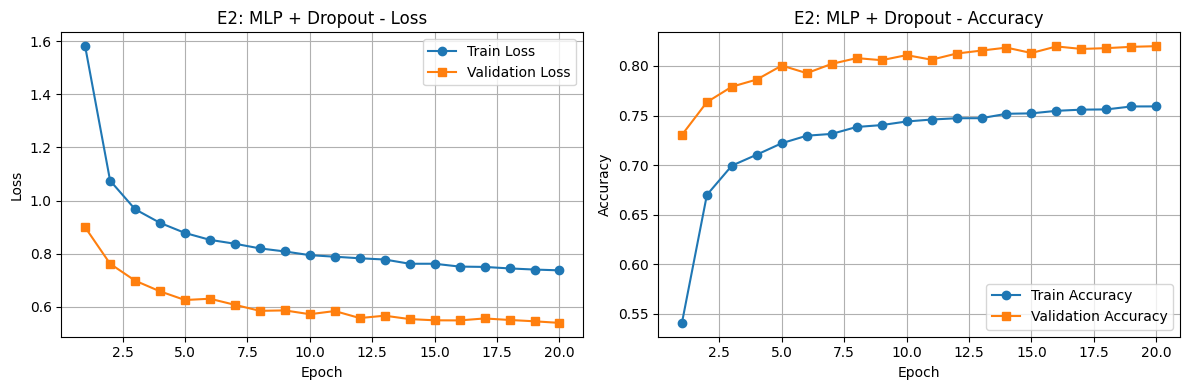

In [ ]:
# Создаём модель для E2: MLP как в E1, но с Dropout
print("Начало эксперимента E2 (Dropout)")
# Определяем архитектуру: та же, что и в BASE_HIDDEN_SIZES, но с Dropout
DROPOUT_P_E2 = 0.3 # Пример вероятности для E2
model_e2 = MLP(
    input_dim=input_size,
    hidden_dims=BASE_HIDDEN_SIZES,
    num_classes=num_classes,
    activation=BASE_ACTIVATION,
    use_batchnorm=False,       
    dropout_p=DROPOUT_P_E2      
).to(device)
# Определяем loss и optimizer для E2 
criterion_e2 = nn.CrossEntropyLoss()
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=BASE_LR)
# Обучаем модель E2
history_e2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(EPOCHS_E1_E2_E3):
    tr_loss, tr_acc = train_one_epoch(model_e2, train_loader, optimizer_e2, criterion_e2, device)
    val_loss, val_acc = evaluate(model_e2, val_loader, criterion_e2, device)
    history_e2['train_loss'].append(tr_loss)
    history_e2['train_acc'].append(tr_acc)
    history_e2['val_loss'].append(val_loss)
    history_e2['val_acc'].append(val_acc)
    print(f"E2 Epoch {epoch+1:02d}/{EPOCHS_E1_E2_E3}| Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f}| Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
# Оцениваем модель E2 на тесте
test_loss_e2, test_acc_e2 = evaluate(model_e2, test_loader, criterion_e2, device)
print(f"E2 Final Test Loss: {test_loss_e2:.4f}, Test Acc: {test_acc_e2:.4f}")
# Построим график для E2
plot_history(history_e2, title="E2: MLP + Dropout")
# Сохраняем модель под именем model_E2
model_E2 = model_e2  # Копируем объект модели
# Сохраняем историю под именем history_E2
history_E2 = history_e2 # Копируем словарь истории
# Сохраняем результаты в словарь results_E2 для runs.csv
results_E2 = {
    'experiment_id': 'E2',
    'dataset': DATASET_NAME,  
    'seed': SEED,             
    'model_summary': f"hidden={BASE_HIDDEN_SIZES}, act={BASE_ACTIVATION}, bn=False, dp={DROPOUT_P_E2}",
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0.0,         # Adam не использует momentum напрямую
    'weight_decay': 0.0,     # Какой был weight_decay (в данном случае 0)
    'epochs_trained': EPOCHS_E1_E2_E3,
    'best_val_accuracy': max(history_e2['val_acc']),  # Лучшая val_acc за всё обучение
    'best_val_loss': min(history_e2['val_loss'])     # Соответствующий val_loss
}

Реализуем эксперимент E3 (BatchNorm)

Начало эксперимента E3 (BatchNorm)
E3 Epoch 01/20| Train Loss: 0.9228, Acc: 0.7361| Val Loss: 0.5844, Acc: 0.8105
E3 Epoch 02/20| Train Loss: 0.5385, Acc: 0.8200| Val Loss: 0.5073, Acc: 0.8321
E3 Epoch 03/20| Train Loss: 0.4651, Acc: 0.8391| Val Loss: 0.4807, Acc: 0.8377
E3 Epoch 04/20| Train Loss: 0.4212, Acc: 0.8507| Val Loss: 0.4629, Acc: 0.8427
E3 Epoch 05/20| Train Loss: 0.3917, Acc: 0.8610| Val Loss: 0.4608, Acc: 0.8484
E3 Epoch 06/20| Train Loss: 0.3642, Acc: 0.8666| Val Loss: 0.4522, Acc: 0.8480
E3 Epoch 07/20| Train Loss: 0.3450, Acc: 0.8718| Val Loss: 0.4500, Acc: 0.8508
E3 Epoch 08/20| Train Loss: 0.3300, Acc: 0.8768| Val Loss: 0.4561, Acc: 0.8460
E3 Epoch 09/20| Train Loss: 0.3118, Acc: 0.8828| Val Loss: 0.4548, Acc: 0.8479
E3 Epoch 10/20| Train Loss: 0.2978, Acc: 0.8879| Val Loss: 0.4586, Acc: 0.8503
E3 Epoch 11/20| Train Loss: 0.2851, Acc: 0.8912| Val Loss: 0.4591, Acc: 0.8531
E3 Epoch 12/20| Train Loss: 0.2756, Acc: 0.8935| Val Loss: 0.4654, Acc: 0.8524
E3 Epoch 13/20| T

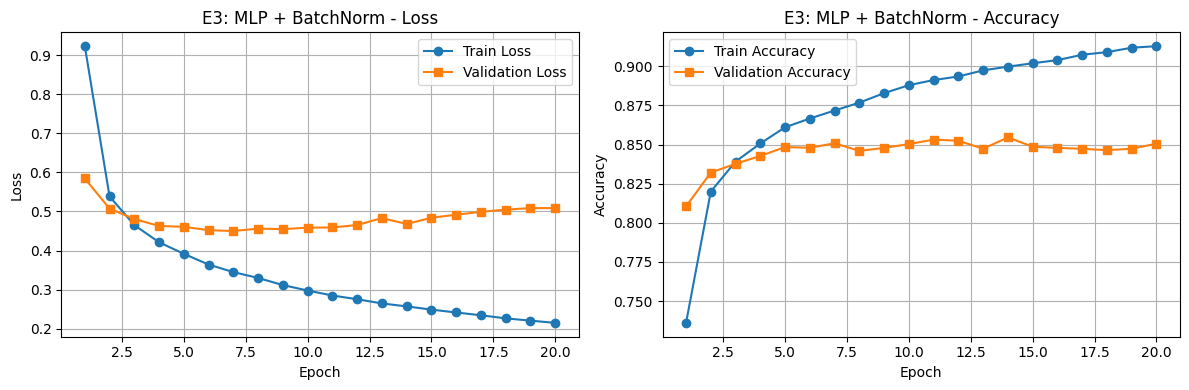

In [ ]:
# Создаём модель для E3: MLP как в E1, но с BatchNorm
print("Начало эксперимента E3 (BatchNorm)")
# Определяем архитектуру
model_e3 = MLP(
    input_dim=input_size,
    hidden_dims=BASE_HIDDEN_SIZES,
    num_classes=num_classes,
    activation=BASE_ACTIVATION,
    use_batchnorm=True,         
    dropout_p=0.0               
).to(device)
# Определяем loss и optimizer для E3 (копируем из E1 для консистентности)
criterion_e3 = nn.CrossEntropyLoss()
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=BASE_LR)
# Обучаем модель E3
history_e3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
for epoch in range(EPOCHS_E1_E2_E3):
    tr_loss, tr_acc = train_one_epoch(model_e3, train_loader, optimizer_e3, criterion_e3, device)
    val_loss, val_acc = evaluate(model_e3, val_loader, criterion_e3, device)
    history_e3['train_loss'].append(tr_loss)
    history_e3['train_acc'].append(tr_acc)
    history_e3['val_loss'].append(val_loss)
    history_e3['val_acc'].append(val_acc)
    print(f"E3 Epoch {epoch+1:02d}/{EPOCHS_E1_E2_E3}| Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f}| Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
# Оцениваем модель E3 на тесте
test_loss_e3, test_acc_e3 = evaluate(model_e3, test_loader, criterion_e3, device)
print(f"E3 Final Test Loss: {test_loss_e3:.4f}, Test Acc: {test_acc_e3:.4f}")
# Построим график для E3 
plot_history(history_e3, title="E3: MLP + BatchNorm")
# Сохраняем модель под именем model_E3
model_E3 = model_e3  # Копируем объект модели
# Сохраняем историю под именем history_E3
history_E3 = history_e3  # Копируем словарь истории
# Сохраняем результаты в словарь results_E3 для runs.csv
results_E3 = {
    'experiment_id': 'E3',
    'dataset': DATASET_NAME,  
    'seed': SEED,             
    'model_summary': f"hidden={BASE_HIDDEN_SIZES}, act={BASE_ACTIVATION}, bn=True, dp=0.0",
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0.0,         # Adam не использует momentum напрямую
    'weight_decay': 0.0,     # Какой был weight_decay (в данном случае 0)
    'epochs_trained': EPOCHS_E1_E2_E3,
    'best_val_accuracy': max(history_e3['val_acc']),  # Лучшая val_acc за всё обучение
    'best_val_loss': min(history_e3['val_loss'])     # Соответствующий val_loss
}

Сравниваем E1, E2, E3 и выбираем лучший для E4

In [ ]:
print("Сравнение E1, E2, E3 по final val_acc")
final_val_acc_e1 = history_e1['val_acc'][-1]
final_val_acc_e2 = history_e2['val_acc'][-1]
final_val_acc_e3 = history_e3['val_acc'][-1]
print(f"E1 (Base) final val_acc: {final_val_acc_e1:.4f}")
print(f"E2 (Dropout) final val_acc: {final_val_acc_e2:.4f}")
print(f"E3 (BatchNorm) final val_acc: {final_val_acc_e3:.4f}")
# Выбираем лучшую модель среди E2 и E3 
if final_val_acc_e2 >= final_val_acc_e3:
    print("Выбрана модель E2 (Dropout) как лучшая из E2/E3 для E4.")
    best_candidate_model = model_e2
    best_candidate_history = history_e2
    best_candidate_name = "E2"
else:
    print("Выбрана модель E3 (BatchNorm) как лучшая из E2/E3 для E4.")
    best_candidate_model = model_e3
    best_candidate_history = history_e3
    best_candidate_name = "E3"

Сравнение E1, E2, E3 по final val_acc
E1 (Base) final val_acc: 0.8323
E2 (Dropout) final val_acc: 0.8200
E3 (BatchNorm) final val_acc: 0.8505
Выбрана модель E3 (BatchNorm) как лучшая из E2/E3 для E4.


Реализуем эксперимент E4 (EarlyStopping)

Начало эксперимента E4 (E3 + EarlyStopping)
E4 Epoch 01/50| Train Loss: 1.1641, Acc: 0.6586| Val Loss: 0.7912, Acc: 0.7518
E4 Epoch 02/50| Train Loss: 0.6637, Acc: 0.7860| Val Loss: 0.6281, Acc: 0.7986
E4 Epoch 03/50| Train Loss: 0.5619, Acc: 0.8124| Val Loss: 0.5826, Acc: 0.8082
E4 Epoch 04/50| Train Loss: 0.5095, Acc: 0.8267| Val Loss: 0.5397, Acc: 0.8273
E4 Epoch 05/50| Train Loss: 0.4741, Acc: 0.8357| Val Loss: 0.5383, Acc: 0.8219
E4 Epoch 06/50| Train Loss: 0.4442, Acc: 0.8440| Val Loss: 0.5203, Acc: 0.8319
E4 Epoch 07/50| Train Loss: 0.4207, Acc: 0.8514| Val Loss: 0.5519, Acc: 0.8219
E4 Epoch 08/50| Train Loss: 0.4053, Acc: 0.8564| Val Loss: 0.5430, Acc: 0.8278
E4 Epoch 09/50| Train Loss: 0.3878, Acc: 0.8592| Val Loss: 0.5391, Acc: 0.8295
E4 Epoch 10/50| Train Loss: 0.3720, Acc: 0.8639| Val Loss: 0.5541, Acc: 0.8251
EarlyStopping: остановка на эпохе 10. Лучший val_acc=0.8319
Лучшие веса (на момент остановки) загружены в модель E4.
EarlyStopping сработал на эпохе 11. Обучение оста

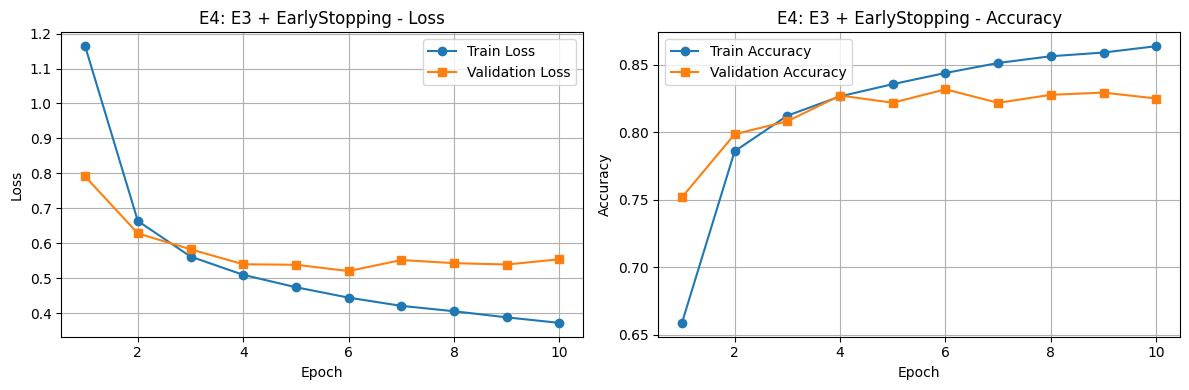

In [ ]:
# Обучаем выбранную лучшую модель (E2 или E3) с EarlyStopping
print(f"Начало эксперимента E4 ({best_candidate_name} + EarlyStopping)")
# Создаём новую модель с той же архитектурой, что и лучший кандидат
# Копируем параметры архитектуры из лучшей модели
arch_kwargs = {
    'input_dim': input_size,
    'hidden_dims': BASE_HIDDEN_SIZES,
    'num_classes': num_classes,
    'activation': BASE_ACTIVATION,
    'use_batchnorm': best_candidate_model.use_batchnorm if hasattr(best_candidate_model, 'use_batchnorm') else False,
    'dropout_p': best_candidate_model.dropout_p if hasattr(best_candidate_model, 'dropout_p') else 0.0,
}
model_e4 = MLP(**arch_kwargs).to(device)
# Инициализируем EarlyStopping, который будет отслеживать val_acc (mode='max')
early_stopper_e4 = EarlyStopping(patience=ES_PATIENCE, min_delta=ES_MIN_DELTA, metric_for_best='acc', mode='max')
# Определяем loss и optimizer для E4 (копируем из E1 для консистентности)
criterion_e4 = nn.CrossEntropyLoss()
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=BASE_LR)
# Обучаем модель E4 с EarlyStopping
history_e4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_e4_so_far = 0.0
stop_flag = False
for epoch in range(ES_EPOCHS_MAX):
    if stop_flag:
        print(f"EarlyStopping сработал на эпохе {epoch+1}. Обучение остановлено.")
        break
    tr_loss, tr_acc = train_one_epoch(model_e4, train_loader, optimizer_e4, criterion_e4, device)
    val_loss, val_acc = evaluate(model_e4, val_loader, criterion_e4, device)
    history_e4['train_loss'].append(tr_loss)
    history_e4['train_acc'].append(tr_acc)
    history_e4['val_loss'].append(val_loss)
    history_e4['val_acc'].append(val_acc)
    print(f"E4 Epoch {epoch+1:02d}/{ES_EPOCHS_MAX}| Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f}| Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    # Проверяем, нужно ли останавливаться
    should_stop = early_stopper_e4.step(val_acc, model_e4)
    if should_stop:
        stop_flag = True
        print(f"EarlyStopping: остановка на эпохе {epoch+1}. Лучший val_acc={early_stopper_e4.best_score:.4f}")
        # EarlyStopping уже сохранил лучшие веса во внутреннее состояние best_state
        # Загружаем их в модель
        early_stopper_e4.load_best_weights(model_e4)
        print("Лучшие веса (на момент остановки) загружены в модель E4.")
# После остановки (или окончания эпох) оцениваем модель E4 на тесте
test_loss_e4, test_acc_e4 = evaluate(model_e4, test_loader, criterion_e4, device)
print(f"E4 Final Test Loss: {test_loss_e4:.4f}, Test Acc: {test_acc_e4:.4f}")
# Построим график для E4
plot_history(history_e4, title=f"E4: {best_candidate_name} + EarlyStopping")
# Сохраняем модель под именем model_E4 (это уже лучшая модель благодаря ES)
model_E4 = model_e4  # Копируем объект модели (с лучшими весами)
# Сохраняем историю под именем history_E4
history_E4 = history_e4  # Копируем словарь истории
# Сохраняем результаты в словарь results_E4 для runs.csv
best_val_acc_from_es = early_stopper_e4.best_score if hasattr(early_stopper_e4, 'best_score') else max(history_e4['val_acc'])
# best_val_loss соответствует эпохе с best_val_acc, найдём её индекс
best_epoch_index = history_e4['val_acc'].index(best_val_acc_from_es)
best_val_loss_from_history = history_e4['val_loss'][best_epoch_index]
results_E4 = {
    'experiment_id': 'E4',
    'dataset': DATASET_NAME,  
    'seed': SEED,             
    'model_summary': f"hidden={BASE_HIDDEN_SIZES}, act={BASE_ACTIVATION}, bn={arch_kwargs['use_batchnorm']}, dp={arch_kwargs['dropout_p']}",
    'optimizer': 'Adam',
    'lr': BASE_LR,
    'momentum': 0.0,         # Adam не использует momentum напрямую
    'weight_decay': 0.0,     # Какой был weight_decay (в данном случае 0)
    'epochs_trained': len(history_e4['train_loss']), # Количество эпох, пройденных до остановки
    'best_val_accuracy': best_val_acc_from_es,  # Лучшая val_acc, найденная ES
    'best_val_loss': best_val_loss_from_history # Соответствующий val_loss
}

Извлекаем параметры архитектуры из model_e4 (лучшей модели из E4)

In [ ]:
def get_arch_from_model(model):
    """
    Возвращает словарь с параметрами архитектуры MLP на основе существующей модели.
    """
    # Ищем скрытые размеры: это все Linear-слои до последнего (output)
    hidden_dims = []
    for layer in model.net:
        if isinstance(layer, nn.Linear):
            # Пропускаем первый (входной) и последний (выходной) слои
            if layer.out_features != num_classes:  # не output-слой
                hidden_dims.append(layer.out_features)
    
    # Определяем, есть ли BatchNorm и Dropout в архитектуре
    has_bn  = any(isinstance(l, nn.BatchNorm1d) for l in model.net)
    has_dp  = any(isinstance(l, nn.Dropout) for l in model.net)
    dropout_p = 0.3 if has_dp else 0.0  # если был Dropout в E2, используем p=0.3
    return {
        'input_dim': input_size,
        'hidden_dims': tuple(hidden_dims),
        'num_classes': num_classes,
        'activation': 'relu',
        'use_batchnorm': has_bn,
        'dropout_p': dropout_p
    }
# Получаем конфигурацию архитектуры
arch_cfg_o = get_arch_from_model(model_e4)
print(f"Архитектура для O1-O3: {arch_cfg_o}")

Архитектура для O1-O3: {'input_dim': 784, 'hidden_dims': (256, 128), 'num_classes': 47, 'activation': 'relu', 'use_batchnorm': False, 'dropout_p': 0.0}


Задаем общие параметры для экспериментов O1-O3

In [ ]:
# Архитектура для O1-O3 - та же, что у E4 (лучшей модели из E1-E3)
ARCH_FOR_O = {
    'input_dim': input_size,
    'hidden_dims': BASE_HIDDEN_SIZES,
    'num_classes': num_classes,
    'activation': BASE_ACTIVATION,
    # Угадываем архитектуру из model_e4
    'use_batchnorm': any(isinstance(layer, nn.BatchNorm1d) for layer in model_e4.net),
    'dropout_p': 0.3 if any(isinstance(layer, nn.Dropout) for layer in model_e4.net) else 0.0,
}
# Параметры обучения для O1-O3
EPOCHS_O = 10  # Количество эпох для O1-O3
CRITERION_O = nn.CrossEntropyLoss() # Общий loss для O1-O3

Реализуем эксперимент O1 (LR слишком большой)

In [ ]:
print("Начало эксперимента O1 (LR слишком большой)")
# Проверяем, что model_e4 существует (лучшая модель из E4)
if 'model_e4' not in globals():
    raise RuntimeError("Ошибка: модель model_e4 не определена. Выполните сначала эксперименты E1–E4.")
# Получаем конфигурацию архитектуры
arch_cfg_o = get_arch_from_model(model_e4)
print(f"Архитектура для O1: {arch_cfg_o}")
# Создаём новую модель с той же архитектурой (чистая инициализация)
model_o1 = MLP(**arch_cfg_o).to(device)
print(f"Модель O1 создана. Кол-во обучаемых параметров: "
      f"{sum(p.numel() for p in model_o1.parameters() if p.requires_grad)}")
# Определяем optimizer с критически большим LR (1e-1)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)  # ← ключевой параметр для O1
criterion_o1 = nn.CrossEntropyLoss()
# Инициализируем историю обучения
history_o1 = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}
# Устанавливаем количество эпох (достаточно 8 для диагностики)
EPOCHS_O = 8
# Обучаем модель
for epoch in range(EPOCHS_O):
    # Обучение на одной эпохе
    tr_loss, tr_acc = train_one_epoch(model_o1, train_loader, optimizer_o1, criterion_o1, device)
    # Проверка на NaN/Inf 
    if not math.isfinite(tr_loss):
        print(f"O1: NaN/Inf в train_loss на эпохе {epoch+1}. Обучение прервано.")
        break
    # Оценка на валидационной выборке
    val_loss, val_acc = evaluate(model_o1, val_loader, criterion_o1, device)
    # Проверка на NaN/Inf для val_loss
    if not math.isfinite(val_loss):
        print(f"O1: NaN/Inf в val_loss на эпохе {epoch+1}. Обучение прервано.")
        break
    # Сохраняем результаты
    history_o1['train_loss'].append(tr_loss)
    history_o1['train_acc'].append(tr_acc)
    history_o1['val_loss'].append(val_loss)
    history_o1['val_acc'].append(val_acc)
    # Выводим прогресс
    print(
        f"O1 Epoch {epoch+1:02d}/{EPOCHS_O} | "
        f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
    )
# Финальная оценка на тесте (только для отчёта)
test_loss_o1, test_acc_o1 = evaluate(model_o1, test_loader, criterion_o1, device)
print(f"\nO1 Final Test Loss: {test_loss_o1:.4f}, Test Acc: {test_acc_o1:.4f}")
# Сохраняем модель под именем model_O1
model_O1 = model_o1  # Копируем объект модели
# Сохраняем историю под именем history_O1
history_O1 = history_o1  # Копируем словарь истории
# Сохраняем результаты в словарь results_O1 для runs.csv
results_O1 = {
    'experiment_id': 'O1',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': (
        f"hidden={arch_cfg_o['hidden_dims']}, "
        f"act={arch_cfg_o['activation']}, "
        f"bn={arch_cfg_o['use_batchnorm']}, "
        f"dp={arch_cfg_o['dropout_p']}"
    ),
    'optimizer': 'Adam',
    'lr': 1e-1,  
    'momentum': 0.0,
    'weight_decay': 0.0,
    'epochs_trained': len(history_o1['train_loss']),
    'best_val_accuracy': max(history_o1['val_acc']) if history_o1['val_acc'] else 0.0,
    'best_val_loss': min(history_o1['val_loss']) if history_o1['val_loss'] else float('inf') # Добавлено для ТЗ
}
print(f"Результаты O1 собраны. Val Acc (max): {results_O1['best_val_accuracy']:.4f}")

Начало эксперимента O1 (LR слишком большой)
Архитектура для O1: {'input_dim': 784, 'hidden_dims': (256, 128), 'num_classes': 47, 'activation': 'relu', 'use_batchnorm': False, 'dropout_p': 0.0}
Модель O1 создана. Кол-во обучаемых параметров: 239919
O1 Epoch 01/8 | Train Loss: 5.2896, Acc: 0.0209 | Val Loss: 3.8770, Acc: 0.0210
O1 Epoch 02/8 | Train Loss: 3.8710, Acc: 0.0207 | Val Loss: 3.8773, Acc: 0.0203
O1 Epoch 03/8 | Train Loss: 3.8704, Acc: 0.0207 | Val Loss: 3.8733, Acc: 0.0215
O1 Epoch 04/8 | Train Loss: 3.8710, Acc: 0.0212 | Val Loss: 3.8679, Acc: 0.0219
O1 Epoch 05/8 | Train Loss: 3.8710, Acc: 0.0211 | Val Loss: 3.8714, Acc: 0.0210
O1 Epoch 06/8 | Train Loss: 3.8705, Acc: 0.0212 | Val Loss: 3.8716, Acc: 0.0211
O1 Epoch 07/8 | Train Loss: 3.8709, Acc: 0.0215 | Val Loss: 3.8808, Acc: 0.0218
O1 Epoch 08/8 | Train Loss: 3.8702, Acc: 0.0215 | Val Loss: 3.8721, Acc: 0.0217

O1 Final Test Loss: 3.8720, Test Acc: 0.0213
Результаты O1 собраны. Val Acc (max): 0.0219


Реализуем эусперимент O2 (LR слишком маленький)

In [ ]:
print("Начало эксперимента O2 (LR слишком маленький)")
# Проверяем, что model_e4 существует (лучшая модель из E4)
if 'model_e4' not in globals():
    raise RuntimeError("Ошибка: модель model_e4 не определена. Выполните сначала эксперименты E1-E4.")
# Получаем конфигурацию архитектуры из лучшей модели E4
# Используем ту же функцию, что и в O1
arch_cfg_o = get_arch_from_model(model_e4)
print(f"Архитектура для O2: {arch_cfg_o}")
# Создаём новую модель с той же архитектурой (чистая инициализация весов)
model_o2 = MLP(**arch_cfg_o).to(device)
print(f"Модель O2 создана. Количество обучаемых параметров: "
      f"{sum(p.numel() for p in model_o2.parameters() if p.requires_grad)}")
# Определяем optimizer с критически **маленьким** learning rate (например, 1e-5)
# Цель: продемонстрировать "замороженное" обучение, где loss и accuracy почти не меняются.
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)  # ключевой параметр для O2
criterion_o2 = nn.CrossEntropyLoss()
# Инициализируем историю обучения
history_o2 = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}
# Устанавливаем количество эпох (достаточно 8 для диагностики)
EPOCHS_O = 8
# Обучаем модель
for epoch in range(EPOCHS_O):
    # Обучение на одной эпохе
    tr_loss, tr_acc = train_one_epoch(model_o2, train_loader, optimizer_o2, criterion_o2, device)
    # Проверка на NaN/Inf (всё равно делаем, хотя мално при малом LR)
    if not math.isfinite(tr_loss):
        print(f"O2: NaN/Inf в train_loss на эпохе {epoch+1}. Обучение прервано.")
        break
    # Оценка на валидационной выборке
    val_loss, val_acc = evaluate(model_o2, val_loader, criterion_o2, device)
    # Проверка на NaN/Inf для val_loss
    if not math.isfinite(val_loss):
        print(f"O2: NaN/Inf в val_loss на эпохе {epoch+1}. Обучение прервано.")
        break
    # Сохраняем результаты эпохи
    history_o2['train_loss'].append(tr_loss)
    history_o2['train_acc'].append(tr_acc)
    history_o2['val_loss'].append(val_loss)
    history_o2['val_acc'].append(val_acc)
    # Выводим прогресс
    print(
        f"O2 Epoch {epoch+1:02d}/{EPOCHS_O} | "
        f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
    )
# Финальная оценка на тестовой выборке (ТОЛЬКО для отчёта, не для выбора модели!)
test_loss_o2, test_acc_o2 = evaluate(model_o2, test_loader, criterion_o2, device)
print(f"O2 Final Test Loss: {test_loss_o2:.4f}, Test Acc: {test_acc_o2:.4f}")
# Сохраняем модель под именем model_O2
model_O2 = model_o2  # Копируем объект модели
# Сохраняем историю под именем history_O2
history_O2 = history_o2  # Копируем словарь истории
# Сохраняем результаты в словарь results_O2 для runs.csv
results_O2 = {
    'experiment_id': 'O2',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': (
        f"hidden={arch_cfg_o['hidden_dims']}, "
        f"act={arch_cfg_o['activation']}, "
        f"bn={arch_cfg_o['use_batchnorm']}, "
        f"dp={arch_cfg_o['dropout_p']}"
    ),
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': 0.0, # Adam не использует momentum напрямую
    'weight_decay': 0.0,
    'epochs_trained': len(history_o2['train_loss']),
    'best_val_accuracy': max(history_o2['val_acc']) if history_o2['val_acc'] else 0.0,
    'best_val_loss': min(history_o2['val_loss']) if history_o2['val_loss'] else float('inf') # Добавлено для ТЗ
}
print(f"Результаты O2 собраны. Val Acc (max): {results_O2['best_val_accuracy']:.4f}")

Начало эксперимента O2 (LR слишком маленький)
Архитектура для O2: {'input_dim': 784, 'hidden_dims': (256, 128), 'num_classes': 47, 'activation': 'relu', 'use_batchnorm': False, 'dropout_p': 0.0}
Модель O2 создана. Количество обучаемых параметров: 239919
O2 Epoch 01/8 | Train Loss: 3.5200, Acc: 0.2008 | Val Loss: 3.0709, Acc: 0.3398
O2 Epoch 02/8 | Train Loss: 2.6467, Acc: 0.4221 | Val Loss: 2.2975, Acc: 0.4778
O2 Epoch 03/8 | Train Loss: 2.0705, Acc: 0.5082 | Val Loss: 1.8975, Acc: 0.5309
O2 Epoch 04/8 | Train Loss: 1.7812, Acc: 0.5471 | Val Loss: 1.6923, Acc: 0.5589
O2 Epoch 05/8 | Train Loss: 1.6216, Acc: 0.5713 | Val Loss: 1.5702, Acc: 0.5788
O2 Epoch 06/8 | Train Loss: 1.5217, Acc: 0.5889 | Val Loss: 1.4887, Acc: 0.5966
O2 Epoch 07/8 | Train Loss: 1.4531, Acc: 0.6012 | Val Loss: 1.4311, Acc: 0.6104
O2 Epoch 08/8 | Train Loss: 1.4025, Acc: 0.6119 | Val Loss: 1.3889, Acc: 0.6163
O2 Final Test Loss: 1.3973, Test Acc: 0.6131
Результаты O2 собраны. Val Acc (max): 0.6163


Реализуем эусперимент O3 (SGD+momentum + weight decay)

In [ ]:
print("Начало эксперимента O3 (SGD + momentum + weight decay)")
# Проверяем, что model_e4 существует (луч4)
if 'model_e4' not in globals():
    raise RuntimeError("Ошибка: модель model_e4 не определена. Выполните сначала эксперименты E1-E4.")
# Получаем конфигурацию архитектуры из лучшей модели E4
arch_cfg_o = get_arch_from_model(model_e4)
print(f"Архитектура для O3: {arch_cfg_o}")
# Создаём новую модель с той же архитектурой (чистая инициализация весов)
model_o3 = MLP(**arch_cfg_o).to(device)
print(f"Модель O3 создана. Количество обучаемых параметров: "
      f"{sum(p.numel() for p in model_o3.parameters() if p.requires_grad)}")
# Определяем optimizer SGD с momentum и weight_decay
optimizer_o3 = optim.SGD(
    model_o3.parameters(),
    lr=1e-3,          # разумный learning rate
    momentum=0.9,      # ускоряет сходимость
    weight_decay=1e-4  
)
criterion_o3 = nn.CrossEntropyLoss()
# Инициализируем историю обучения
history_o3 = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}
# Устанавливаем количество эпох
EPOCHS_O = 10
# Обучаем модель
for epoch in range(EPOCHS_O):
    # Обучение на одной эпохе
    tr_loss, tr_acc = train_one_epoch(model_o3, train_loader, optimizer_o3, criterion_o3, device)
    # Проверка на NaN/Inf (используем math.isfinite для float)
    if not math.isfinite(tr_loss):
        print(f"O3: NaN/Inf в train_loss на эпохе {epoch+1}. Обучение прервано.")
        break
    # Оценка на валидационной выборке
    val_loss, val_acc = evaluate(model_o3, val_loader, criterion_o3, device)
    # Проверка на NaN/Inf для val_loss
    if not math.isfinite(val_loss):
        print(f"O3: NaN/Inf в val_loss на эпохе {epoch+1}. Обучение прервано.")
        break
    # Сохраняем результаты
    history_o3['train_loss'].append(tr_loss)
    history_o3['train_acc'].append(tr_acc)
    history_o3['val_loss'].append(val_loss)
    history_o3['val_acc'].append(val_acc)
    # Выводим прогресс
    print(
        f"O3 Epoch {epoch+1:02d}/{EPOCHS_O} | "
        f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
    )
# Финальная оценка на тесте (только для отчёта)
test_loss_o3, test_acc_o3 = evaluate(model_o3, test_loader, criterion_o3, device)
print(f"\nO3 Final Test Loss: {test_loss_o3:.4f}, Test Acc: {test_acc_o3:.4f}")
# Сохраняем модель под именем model_O3
model_O3 = model_o3  # Копируем объект модели
# Сохраняем историю под именем history_O3
history_O3 = history_o3  # Копируем словарь истории
# Сохраняем результаты в словарь results_O3 для runs.csv
results_O3 = {
    'experiment_id': 'O3',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': (
        f"hidden={arch_cfg_o['hidden_dims']}, "
        f"act={arch_cfg_o['activation']}, "
        f"bn={arch_cfg_o['use_batchnorm']}, "
        f"dp={arch_cfg_o['dropout_p']}"
    ),
    'optimizer': 'SGD',
    'lr': 1e-3,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': len(history_o3['train_loss']),
    'best_val_accuracy': max(history_o3['val_acc']) if history_o3['val_acc'] else 0.0,
    'best_val_loss': min(history_o3['val_loss']) if history_o3['val_loss'] else float('inf')
}
print(f"Результаты O3 собраны. Val Acc (max): {results_O3['best_val_accuracy']:.4f}")

Начало эксперимента O3 (SGD + momentum + weight decay)
Архитектура для O3: {'input_dim': 784, 'hidden_dims': (256, 128), 'num_classes': 47, 'activation': 'relu', 'use_batchnorm': False, 'dropout_p': 0.0}
Модель O3 создана. Количество обучаемых параметров: 239919
O3 Epoch 01/10 | Train Loss: 2.7856, Acc: 0.3243 | Val Loss: 1.6728, Acc: 0.5429
O3 Epoch 02/10 | Train Loss: 1.4458, Acc: 0.5928 | Val Loss: 1.3154, Acc: 0.6306
O3 Epoch 03/10 | Train Loss: 1.2414, Acc: 0.6464 | Val Loss: 1.1906, Acc: 0.6606
O3 Epoch 04/10 | Train Loss: 1.1279, Acc: 0.6761 | Val Loss: 1.0956, Acc: 0.6857
O3 Epoch 05/10 | Train Loss: 1.0331, Acc: 0.7018 | Val Loss: 1.0213, Acc: 0.7088
O3 Epoch 06/10 | Train Loss: 0.9489, Acc: 0.7230 | Val Loss: 0.9370, Acc: 0.7273
O3 Epoch 07/10 | Train Loss: 0.8744, Acc: 0.7421 | Val Loss: 0.8613, Acc: 0.7519
O3 Epoch 08/10 | Train Loss: 0.8117, Acc: 0.7578 | Val Loss: 0.8105, Acc: 0.7630
O3 Epoch 09/10 | Train Loss: 0.7594, Acc: 0.7712 | Val Loss: 0.7727, Acc: 0.7682
O3 Epoch

Проверяем наличие подготовленных переменных

In [ ]:
# Проверяем, что все эксперименты были выполнены и результаты сохранены.
required_results = ['results_E1', 'results_E2', 'results_E3', 'results_E4', 'results_O1', 'results_O2', 'results_O3']
missing_results = [r for r in required_results if r not in globals()]
if missing_results:
    raise RuntimeError(f"Ошибка: не найдены переменные с результатами: {missing_results}. Выполните все эксперименты (E1-O3).")
# Также проверяем наличие моделей и историй, нужных для артефактов.
required_for_artifacts = ['model_E4', 'history_E4', 'history_O1', 'history_O2']
missing_artifacts = [m for m in required_for_artifacts if m not in globals()]
if missing_artifacts:
    print(f"Предупреждение: не найдены переменные: {missing_artifacts}.")
    print("Некоторые артефакты (графики) могут не быть созданы.")
print("Все подготовленные переменные для артефактов найдены.")

Все подготовленные переменные для артефактов найдены.


Создаем директории artifacts и figures

In [ ]:
# Создаём основную папку для артефактов и подпапку для графиков.
artifacts_dir = './artifacts'  # Корневая папка артефактов
figures_dir = os.path.join(artifacts_dir, 'figures')  # Подпапка для графиков, как рекомендовано в ТЗ.
os.makedirs(figures_dir, exist_ok=True)  # Создаём обе папки, если их нет.
print(f"Папки '{artifacts_dir}' и '{figures_dir}' созданы.")

Папки './artifacts' и './artifacts\figures' созданы.


Сохраняем `best_model.pt`

In [ ]:
# Лучшая модель (model_E4) была выбрана в E4 и обучена с EarlyStopping.
best_model_path = os.path.join(artifacts_dir, 'best_model.pt')  # Путь к файлу модели.
torch.save(model_E4.state_dict(), best_model_path)  # Сохраняем только веса, а не всю модель.
print(f"best_model.pt сохранён: {best_model_path}")

best_model.pt сохранён: ./artifacts\best_model.pt


Сохраняем `best_config.json`

In [ ]:
# Извлекаем архитектуру из model_E4 
def extract_architecture(model):
    """
    Извлекает информацию об архитектуре MLP.
    :param model: Объект nn.Module (например, model_E4).
    :return: Словарь с параметрами архитектуры.
    """
    hidden_dims = []
    for layer in model.net:
        if isinstance(layer, torch.nn.Linear) and layer.out_features != num_classes:
            # Извлекаем размеры скрытых слоёв, исключая выходной
            hidden_dims.append(layer.out_features)
    has_bn = any(isinstance(l, torch.nn.BatchNorm1d) for l in model.net)
    has_dp = any(isinstance(l, torch.nn.Dropout) for l in model.net)
    dropout_p = 0.3 if has_dp else 0.0
    return {
        "input_dim": input_size,      # Размерность входа (например, 784 для 28x28)
        "hidden_dims": hidden_dims,   # Размеры скрытых слоёв (например, [256, 128])
        "num_classes": num_classes,   # Число классов датасета
        "activation": "relu",         # Используемая активация
        "use_batchnorm": has_bn,      # Использовался ли BatchNorm
        "dropout_p": dropout_p,       # Вероятность Dropout (если был)
    }
# Архитектура модели
architecture_part = extract_architecture(model_E4)
# Гиперпараметры обучения (берём из E4 и общих параметров)
training_hyperparams = {
    "learning_rate": BASE_LR,                  # 1e-3
    "optimizer": "Adam",                       # Явно указан в E4
    "weight_decay": 0.0,                      # Adam в E4 использовал default.0
    "momentum_for_optimizer": 0.0,            # Adam не использует momentum
    "early_stopping_patience": ES_PATIENCE,   # 4
    "early_stopping_min_delta": ES_MIN_DELTA, # 0.0005
    "early_stopping_metric": "acc",           # Как в EarlyStopping: metric_for_best='acc'
    "max_epochs_if_no_es": ES_EPOCHS_MAX,     # Максимальное число эпох, если ES не сработал (50)
}
# Метаданные
metadata = {
    "seed": SEED,
    "dataset": DATASET_NAME,
    "description": "Конфигурация лучшей модели (E4): BatchNorm + EarlyStopping + гиперпараметры обучения"
}
# Объединяем всё в один словарь
full_best_config = {
    **architecture_part,        # Распаковываем архитектуру
    **training_hyperparams,     # Распаковываем гиперпараметры обучения
    **metadata                  # Распаковываем метаданные
}

# Сохраняем полный конфиг
config_path = os.path.join(artifacts_dir, 'best_config.json')
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(full_best_config, f, indent=4, ensure_ascii=False)
print(f"best_config.json сохранён: {config_path}")

best_config.json сохранён: ./artifacts\best_config.json


Сохраняем `figures/curves_best.png`

In [ ]:
# Используем history_E4, содержащий метрики train/val по эпохам.
def plot_and_save_curves(history, title, save_path):
    """
    Строит и сохраняет графики loss и accuracy по истории.
    :param history: словарь с ключами ['train_loss', 'val_loss', 'train_acc', 'val_acc'].
    :param title: заголовок графика.
    :param save_path: путь для сохранения .png файла.
    """
    epochs = list(range(1, len(history['train_loss']) + 1))  # Номера эпох
    plt.figure(figsize=(12, 4))  # Устанавливаем размер фигуры
    # Левый подграфик: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    # Правый подграфик: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # Оптимизируем расположение подграфиков
    os.makedirs(os.path.dirname(save_path), exist_ok=True)  # Убедимся, что папка существует
    plt.savefig(save_path, dpi=150, bbox_inches='tight')  # Сохраняем с высоким качеством
    plt.close()  # Закрываем фигуру, чтобы освободить память
    print(f"График сохранён: {save_path}")
# Сохраняем график для E4, если history_E4 существует
if 'history_E4' in globals():
    plot_and_save_curves(
        history_E4,
        title=f"E4: {results_E4.get('model_summary', 'Best Model')}",
        save_path=os.path.join(figures_dir, 'curves_best.png')  # Имя файла, как в ТЗ.
    )
else:
    print("history_E4 не найдена. График curves_best.png не будет построен.")

График сохранён: ./artifacts\figures\curves_best.png


Сохраняем `figures/curves_lr_extremes.png`

In [ ]:
# Используем history_O1 и history_O2.
def plot_lr_comparison(h1, h2, title1, title2, save_path):
    """
    Строит и сохраняет график сравнения двух историй (O1 vs O2).
    :param h1, h2: словари с историей обучения (history_O1, history_O2).
    :param title1, title2: названия для легенды (O1, O2).
    :param save_path: путь для сохранения .png файла.
    """
    epochs1 = list(range(1, len(h1['train_loss']) + 1))
    epochs2 = list(range(1, len(h2['train_loss']) + 1))
    plt.figure(figsize=(12, 4))
    # Левый подграфик: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs1, h1['train_loss'], label=f'{title1} Train Loss', marker='o')
    plt.plot(epochs1, h1['val_loss'], label=f'{title1} Val Loss', linestyle='--', marker='s')
    plt.plot(epochs2, h2['train_loss'], label=f'{title2} Train Loss', marker='^')
    plt.plot(epochs2, h2['val_loss'], label=f'{title2} Val Loss', linestyle='--', marker='v')
    plt.title('Loss: O1 vs O2')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    # Правый подграфик: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs1, h1['train_acc'], label=f'{title1} Train Acc', marker='o')
    plt.plot(epochs1, h1['val_acc'], label=f'{title1} Val Acc', linestyle='--', marker='s')
    plt.plot(epochs2, h2['train_acc'], label=f'{title2} Train Acc', marker='^')
    plt.plot(epochs2, h2['val_acc'], label=f'{title2} Val Acc', linestyle='--', marker='v')
    plt.title('Accuracy: O1 vs O2')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"График сохранён: {save_path}")
# Сохраняем график O1 vs O2, если history_O1 и history_O2 существуют
if 'history_O1' in globals() and 'history_O2' in globals():
    plot_lr_comparison(
        history_O1, history_O2,
        "O1 (High LR)", "O2 (Low LR)",
        save_path=os.path.join(figures_dir, 'curves_lr_extremes.png')  # Имя файла, как в ТЗ.
    )
else:
    print("history_O1 или history_O2 не найдены. График curves_lr_extremes.png не будет построен.")

График сохранён: ./artifacts\figures\curves_lr_extremes.png


Сохраняем `runs.csv`

In [ ]:
# Собираем все результаты из подготовленных словарей (results_E1, ..., results_O3).
runs_csv_path = os.path.join(artifacts_dir, 'runs.csv')  # Путь к файлу, как в ТЗ.
# Определяем заголовки столбцов CSV строго по ТЗ.
fieldnames = [
    'experiment_id',      # ID эксперимента 
    'dataset',            # Имя датасета 
    'seed',               # Использованный seed
    'model_summary',      # Краткое описание архитектуры
    'optimizer',          # Использованный оптимизатор (Adam, SGD)
    'lr',                 # Learning rate
    'momentum',           # Momentum (0 для Adam)
    'weight_decay',       # Weight decay (0 если не использовался)
    'epochs_trained',     # Количество эпох обучения
    'best_val_accuracy',  # Лучшая достигнутая val_accuracy
    'best_val_loss'       # Соответствующий val_loss
]
# Собираем все результаты в один список
all_results = [results_E1, results_E2, results_E3, results_E4, results_O1, results_O2, results_O3]
# Открываем файл и записываем
with open(runs_csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)  # Создаём объект записи
    writer.writeheader()  # Записываем заголовки столбцов
    for res in all_results:
        # Фильтруем словарь результата, оставляя только нужные ключи
        row = {key: res.get(key) for key in fieldnames}
        writer.writerow(row)  # Записываем строку результата
print(f"runs.csv сохранён: {runs_csv_path}")

runs.csv сохранён: ./artifacts\runs.csv


Выводим список созданных файлов

In [ ]:
print("Артефакты успешно созданы")
print(f"- {best_model_path}")
print(f"- {config_path}")
print(f"- {runs_csv_path}")
if 'history_E4' in globals():
    print(f"- {os.path.join(figures_dir, 'curves_best.png')}")
if 'history_O1' in globals() and 'history_O2' in globals():
    print(f"- {os.path.join(figures_dir, 'curves_lr_extremes.png')}")
print("\nВсе артефакты готовы в папке ./artifacts/")

Артефакты успешно созданы
- ./artifacts\best_model.pt
- ./artifacts\best_config.json
- ./artifacts\runs.csv
- ./artifacts\figures\curves_best.png
- ./artifacts\figures\curves_lr_extremes.png

Все артефакты готовы в папке ./artifacts/
